# Bitcoin Daily - Exploratory Data Analysis

This notebook explores the Bitcoin Daily price dataset.

**Dataset:** `btc-daily.csv`

**Description:** Daily Bitcoin price data (Spanish format) including last price, open, high, low, volume, and percentage change from 2013 to present.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_PATH = Path('../../../data/raw/btc-daily.csv')

## 1. Load and Clean Data

In [2]:
# Load dataset
df = pd.read_csv(DATA_PATH)

# Display first rows
print("First 5 rows (raw):")
display(df.head())

# Clean column names (Spanish to English)
df.columns = ['Date', 'Last', 'Open', 'High', 'Low', 'Vol.', 'Change %']

# Parse date (format: DD.MM.YYYY)
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')

# Clean numeric columns (Spanish format: comma as decimal separator, dot as thousands)
numeric_cols = ['Last', 'Open', 'High', 'Low']
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)

# Clean Volume column (handles K, M, B suffixes)
def clean_volume(v):
    if pd.isna(v) or v == '' or v == '-':
        return np.nan
    v = str(v).replace('.', '').replace(',', '.').upper()
    if 'K' in v:
        return float(v.replace('K', '')) * 1e3
    if 'M' in v:
        return float(v.replace('M', '')) * 1e6
    if 'B' in v:
        return float(v.replace('B', '')) * 1e9
    try:
        return float(v)
    except:
        return np.nan

if 'Vol.' in df.columns:
    df['Vol.'] = df['Vol.'].apply(clean_volume)

# Clean percentage column
df['Change %'] = df['Change %'].str.replace('%', '').str.replace(',', '.').astype(float)

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

print("\nCleaned dataset:")
display(df.head())
print("\nData types:")
print(df.dtypes)

First 5 rows (raw):


,Fecha,Último,Apertura,Máximo,Mínimo,Vol.,% var.
0,03.02.2026,"78.296,2","78.725,6","79.158,4","77.652,4","86,69K","-0,54%"
1,02.02.2026,"78.720,6","76.956,6","79.251,0","74.635,5","124,03K","2,27%"
2,01.02.2026,"76.976,1","78.720,6","79.355,0","75.766,8","76,61K","-2,22%"
3,31.01.2026,"78.726,5","84.227,7","84.240,8","75.993,4","105,81K","-6,54%"
4,30.01.2026,"84.235,5","84.657,0","84.705,1","81.201,5","109,59K","-0,51%"



Cleaned dataset:


,Date,Last,Open,High,Low,Vol.,Change %
0,2014-01-03,884.3,856.9,888.2,839.4,9710.0,3.19
1,2014-01-04,924.7,884.3,932.2,848.3,14240.0,4.57
2,2014-01-05,1014.7,924.7,1029.9,911.4,21370.0,9.74
3,2014-01-06,1012.7,1014.7,1093.4,964.7,23080.0,-0.21
4,2014-01-07,879.9,1012.7,1044.0,879.8,22670.0,-13.11



Data types:
Date        datetime64[ns]
Last               float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %           float64
dtype: object


## 2. Data Overview

In [3]:
print("Dataset Shape:", df.shape)
print("\nDate range:", df['Date'].min(), "to", df['Date'].max())
print("Total trading days:", len(df))
print("\nDataset Info:")
df.info()

Dataset Shape: (4415, 7)

Date range: 2014-01-03 00:00:00 to 2026-02-03 00:00:00
Total trading days: 4415

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4415 entries, 0 to 4414
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4415 non-null   datetime64[ns]
 1   Last      4415 non-null   float64       
 2   Open      4415 non-null   float64       
 3   High      4415 non-null   float64       
 4   Low       4415 non-null   float64       
 5   Vol.      4415 non-null   float64       
 6   Change %  4415 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 241.6 KB


## 3. Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print("Missing Values Summary:")
display(missing_df[missing_df['Missing Count'] > 0])
if missing.sum() == 0:
    print("\n✓ No missing values found!")

Missing Values Summary:


,Missing Count,Percentage



✓ No missing values found!


## 4. Descriptive Statistics

In [5]:
print("Descriptive Statistics:")
display(df[['Last', 'Open', 'High', 'Low', 'Vol.', 'Change %']].describe())

Descriptive Statistics:


,Last,Open,High,Low,Vol.,Change %
count,4415.000000,4415.000000,4415.000000,4415.000000,4.415000e+03,4415.000000
mean,25791.142197,25773.438664,26300.889604,25210.100045,1.399642e+07,0.232088
std,31703.231399,31695.070776,32230.217848,31121.153239,1.647485e+08,6.625062
min,111.600000,111.600000,160.100000,91.700000,2.600000e+02,-57.210000
25%,943.850000,942.450000,972.100000,916.650000,4.590000e+04,-1.265000
50%,9772.000000,9768.800000,9983.600000,9517.400000,8.510000e+04,0.080000
75%,40891.000000,40838.700000,42089.600000,39618.350000,2.234350e+05,1.630000
max,124725.100000,124687.500000,126186.000000,123144.600000,4.470000e+09,336.840000


## 5. Price Time Series

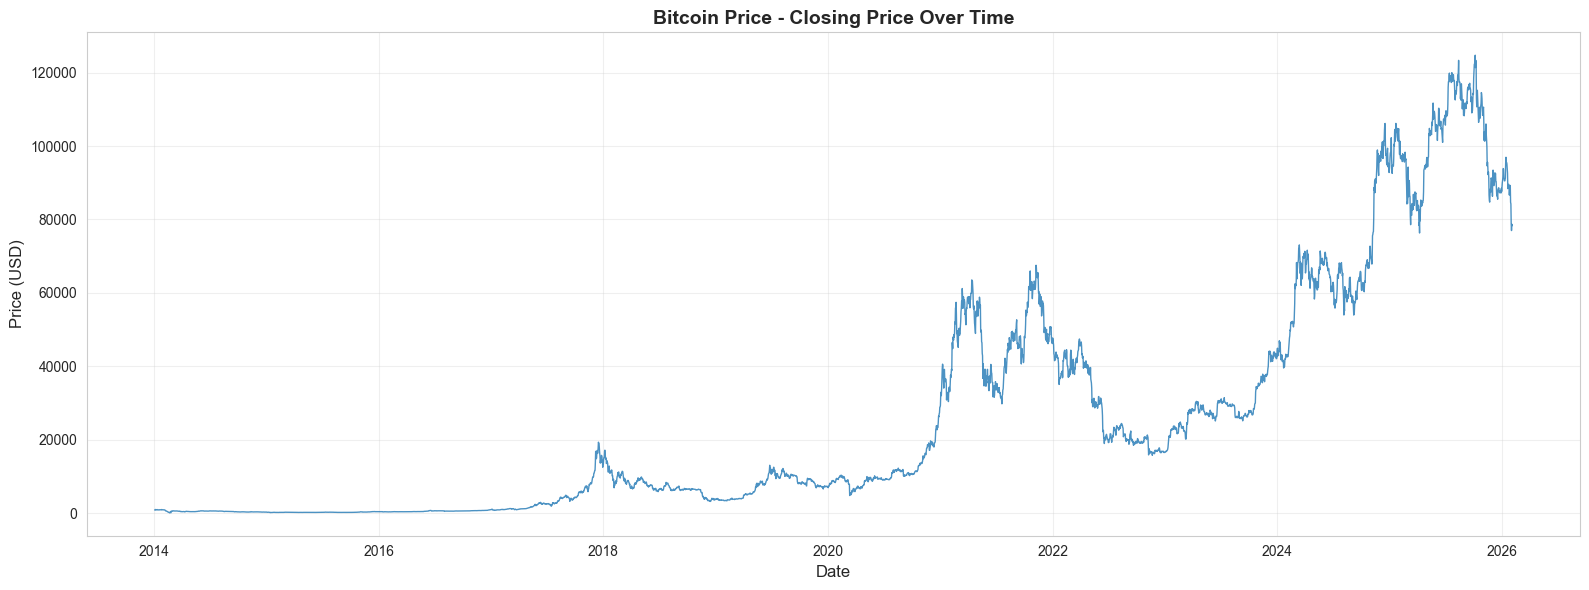

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Last'], linewidth=1, alpha=0.8)
ax.set_title('Bitcoin Price - Closing Price Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

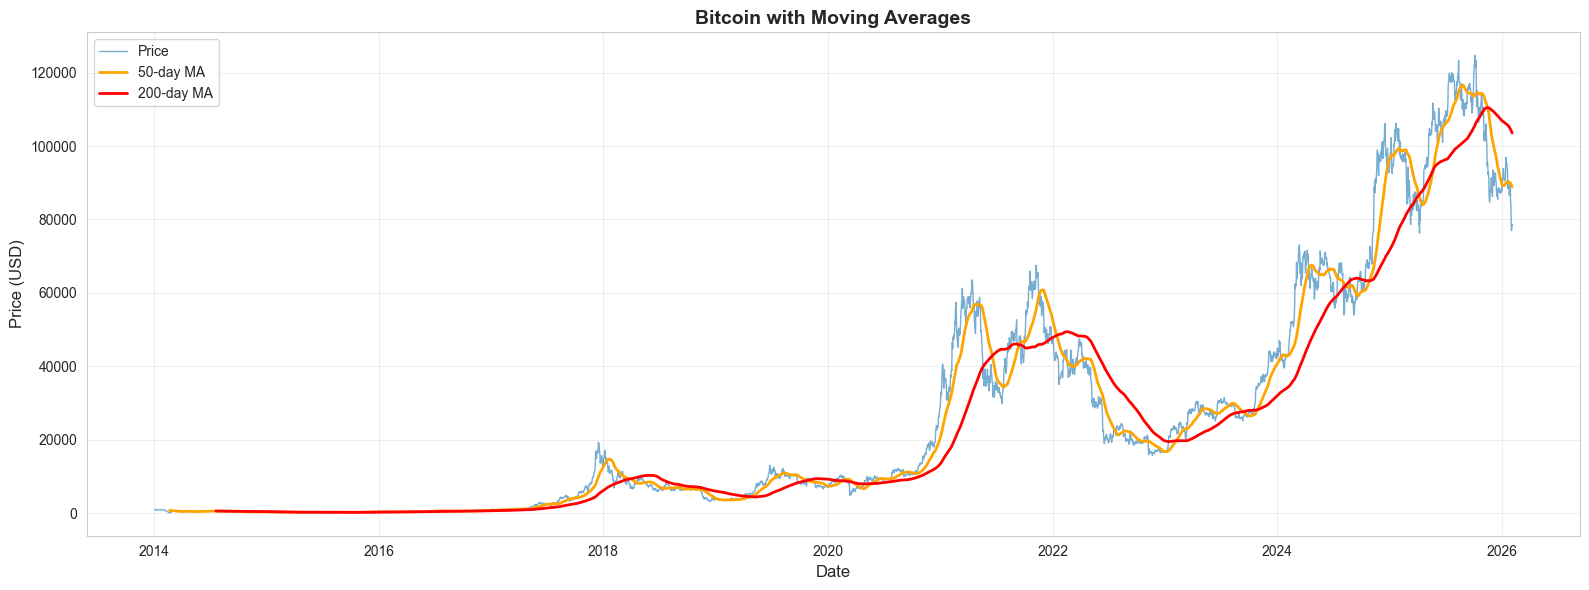

In [7]:
# Moving averages
df['MA_50'] = df['Last'].rolling(window=50).mean()
df['MA_200'] = df['Last'].rolling(window=200).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Last'], linewidth=1, alpha=0.6, label='Price')
ax.plot(df['Date'], df['MA_50'], linewidth=2, label='50-day MA', color='orange')
ax.plot(df['Date'], df['MA_200'], linewidth=2, label='200-day MA', color='red')
ax.set_title('Bitcoin with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Log Scale Analysis

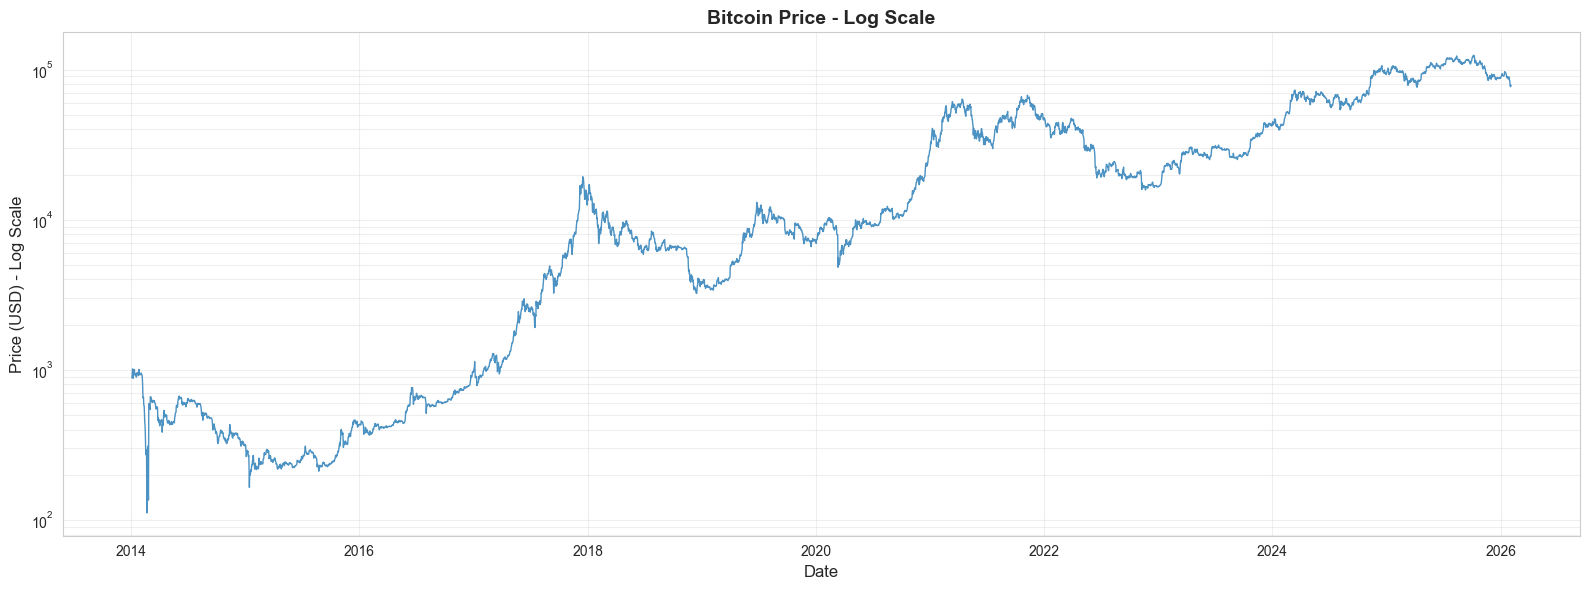

In [8]:
# Bitcoin price in log scale (better for exponential growth)
fig, ax = plt.subplots(figsize=(16, 6))
ax.semilogy(df['Date'], df['Last'], linewidth=1, alpha=0.8)
ax.set_title('Bitcoin Price - Log Scale', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD) - Log Scale', fontsize=12)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 7. Returns Analysis

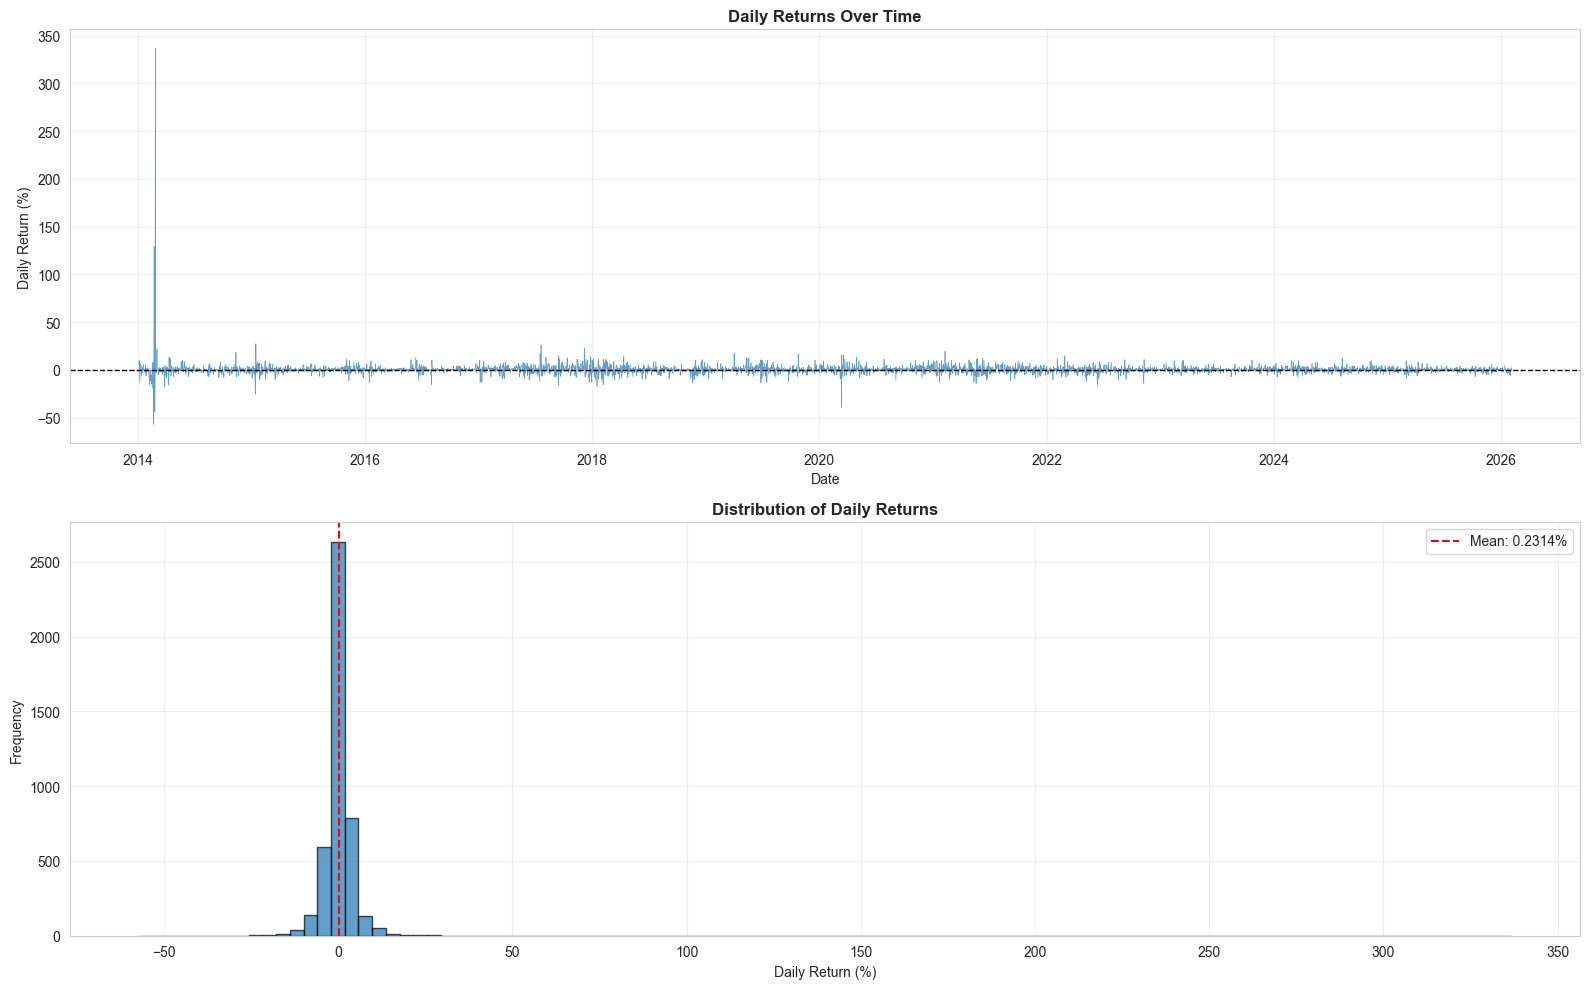

In [9]:
df['Daily_Return'] = df['Last'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(df['Date'], df['Daily_Return'], linewidth=0.5, alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Daily Returns Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Daily Return (%)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['Daily_Return'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[1].axvline(df['Daily_Return'].mean(), color='red', linestyle='--', label=f'Mean: {df["Daily_Return"].mean():.4f}%')
axes[1].set_title('Distribution of Daily Returns', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Volatility Analysis

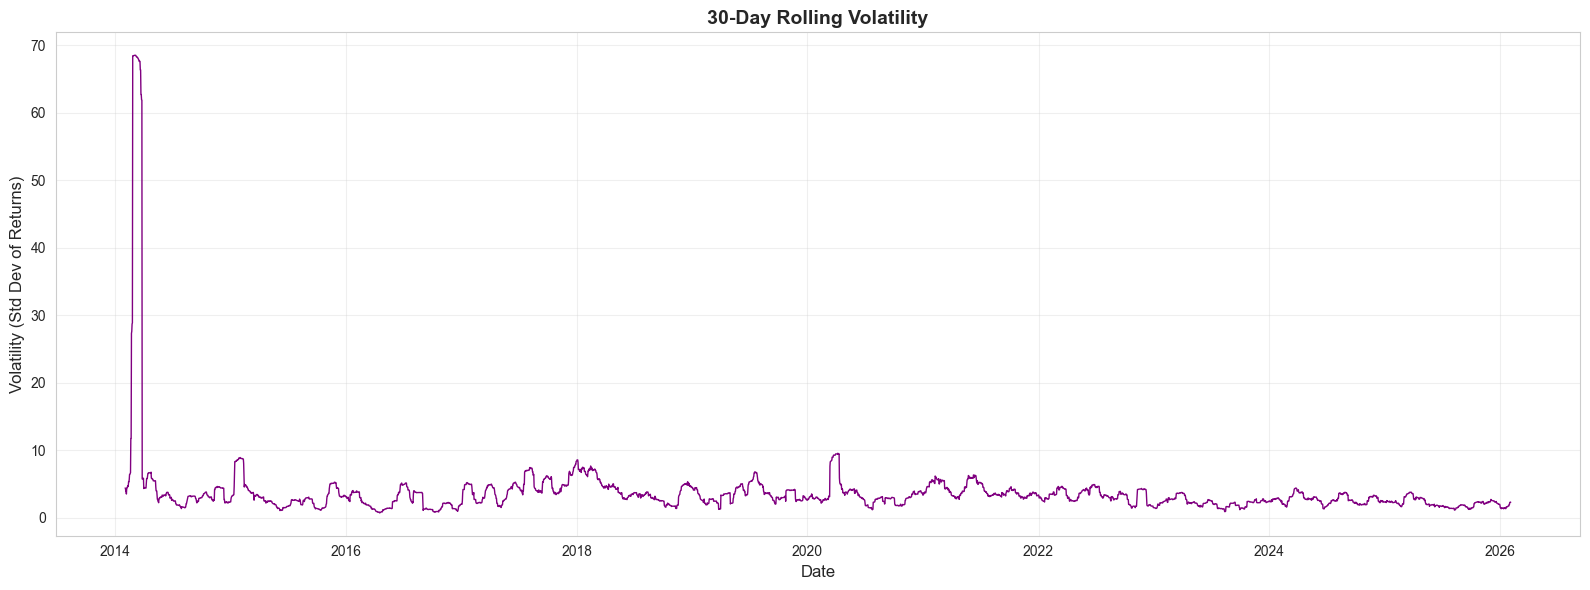

In [10]:
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Volatility_30d'], linewidth=1, color='purple')
ax.set_title('30-Day Rolling Volatility', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volatility (Std Dev of Returns)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Volume Analysis

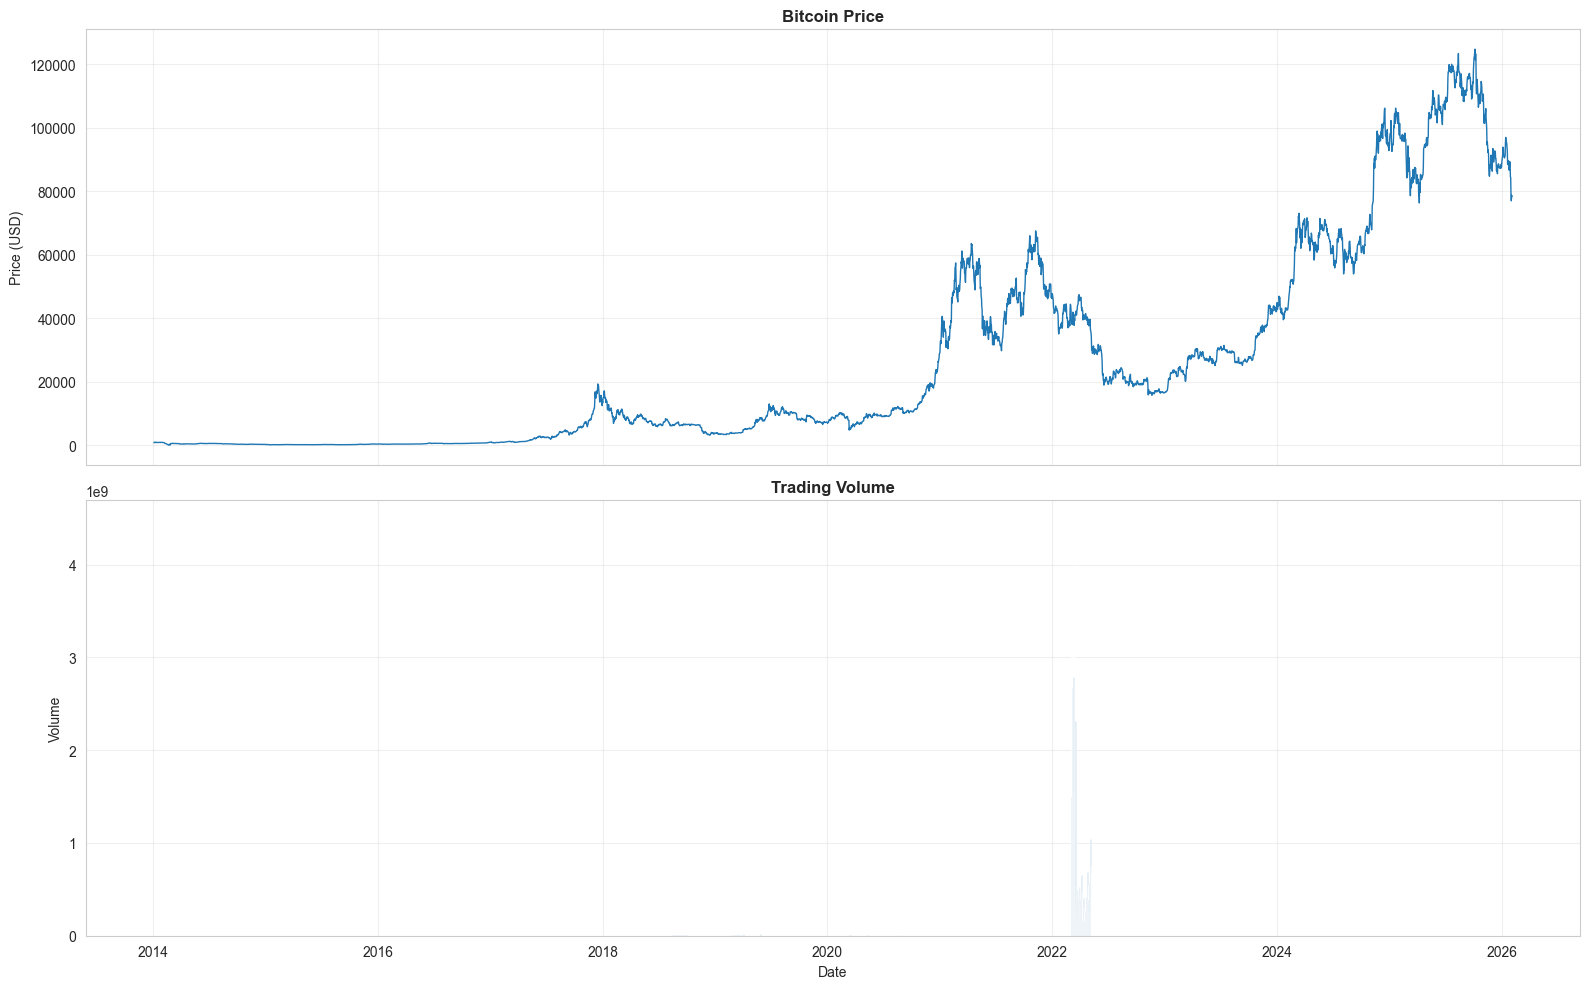

In [11]:
# Plot trading volume
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Price
axes[0].plot(df['Date'], df['Last'], linewidth=1)
axes[0].set_title('Bitcoin Price', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)

# Volume
axes[1].bar(df['Date'], df['Vol.'], width=1, alpha=0.7)
axes[1].set_title('Trading Volume', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volume')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Yearly Performance

Yearly Statistics:


,mean,std,min,max,count
Year,,,,,
2014,521.163912,175.167641,111.6,1014.7,363
2015,272.024110,58.923101,164.9,463.2,365
2016,566.997814,138.349637,368.0,972.2,366
2017,3981.072329,3987.175682,785.4,19345.5,365
2018,7552.158356,2425.518263,3228.7,17172.3,365
2019,7371.821918,2649.945229,3397.7,13063.8,365
2020,11111.631148,4310.343419,4826.0,28949.4,366
2021,47410.840000,9775.209370,29359.9,67527.9,365
2022,28185.670959,10192.406143,15776.2,47738.0,365


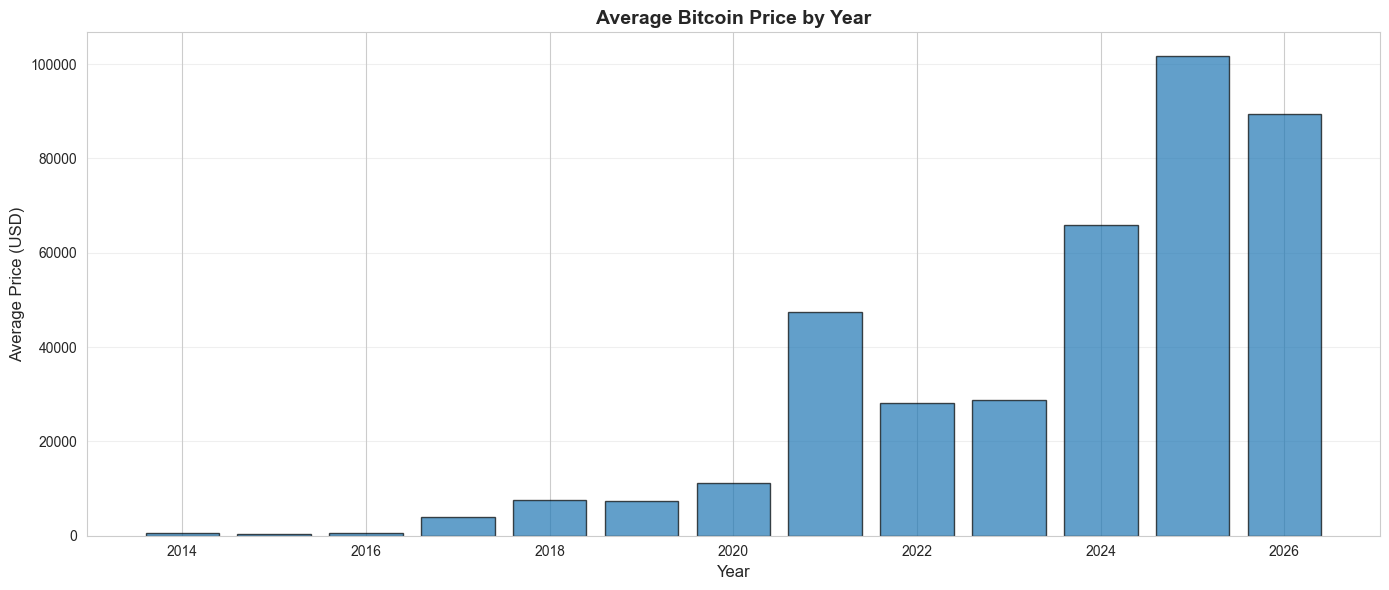

In [12]:
# Extract year
df['Year'] = df['Date'].dt.year

# Yearly statistics
yearly_stats = df.groupby('Year')['Last'].agg(['mean', 'std', 'min', 'max', 'count'])
print("Yearly Statistics:")
display(yearly_stats)

# Plot yearly average
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(yearly_stats.index, yearly_stats['mean'], alpha=0.7, edgecolor='black')
ax.set_title('Average Bitcoin Price by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Price (USD)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 11. Bull/Bear Markets

In [13]:
# Identify major peaks and troughs
top_10_prices = df.nlargest(10, 'Last')[['Date', 'Last']]
print("Top 10 Highest Prices:")
display(top_10_prices)

bottom_10_prices = df.nsmallest(10, 'Last')[['Date', 'Last']]
print("\nTop 10 Lowest Prices:")
display(bottom_10_prices)

Top 10 Highest Prices:


,Date,Last
4294,2025-10-06,124725.1
4293,2025-10-05,123475.5
4240,2025-08-13,123323.4
4296,2025-10-08,123311.1
4292,2025-10-04,122387.1
4291,2025-10-03,122224.2
4297,2025-10-09,121666.3
4295,2025-10-07,121356.6
4290,2025-10-02,120566.1
4239,2025-08-12,120146.2



Top 10 Lowest Prices:


,Date,Last
49,2014-02-21,111.6
48,2014-02-20,111.9
53,2014-02-25,135.8
376,2015-01-14,164.9
52,2014-02-24,174.0
379,2015-01-17,199.6
378,2015-01-16,206.9
377,2015-01-15,209.8
380,2015-01-18,210.6
382,2015-01-20,210.6


## 12. Correlation Analysis

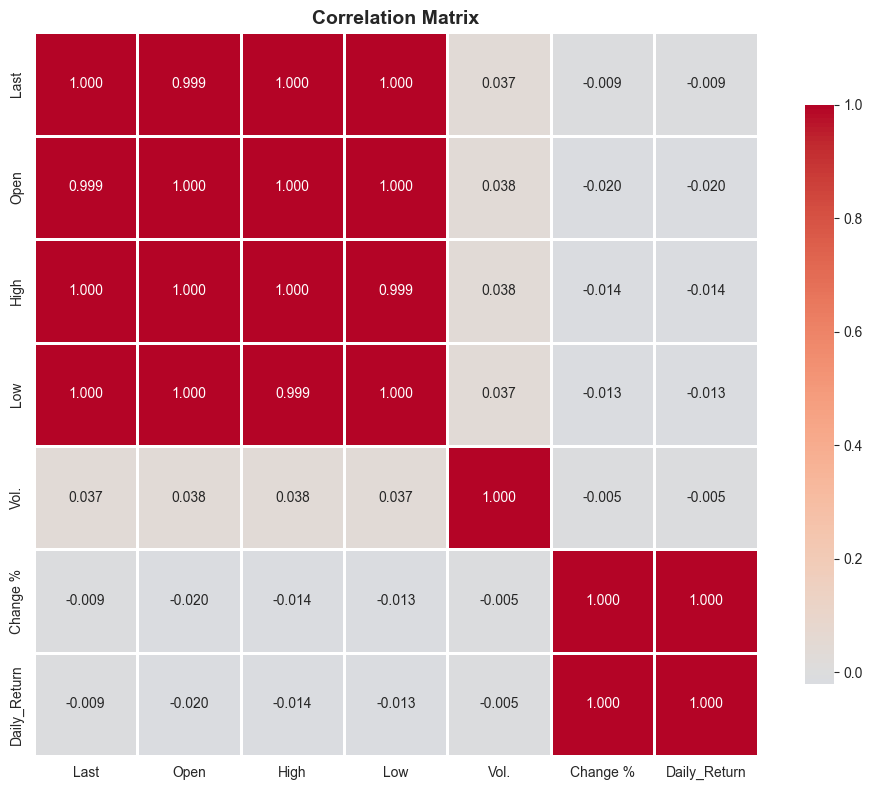

In [14]:
# Correlation matrix
corr_cols = ['Last', 'Open', 'High', 'Low', 'Vol.', 'Change %', 'Daily_Return']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Summary

In [15]:
print("=" * 60)
print("KEY FINDINGS - BITCOIN DAILY")
print("=" * 60)
print(f"\n1. Dataset Coverage:")
print(f"   - Start: {df['Date'].min().strftime('%Y-%m-%d')}")
print(f"   - End: {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"   - Days: {len(df):,}")
print(f"\n2. Price Statistics:")
print(f"   - Current: ${df['Last'].iloc[-1]:,.2f}")
print(f"   - All-time High: ${df['Last'].max():,.2f} ({df.loc[df['Last'].idxmax(), 'Date'].strftime('%Y-%m-%d')})")
print(f"   - All-time Low: ${df['Last'].min():,.2f} ({df.loc[df['Last'].idxmin(), 'Date'].strftime('%Y-%m-%d')})")
print(f"   - Average: ${df['Last'].mean():,.2f}")
print(f"\n3. Returns:")
print(f"   - Avg Daily Return: {df['Daily_Return'].mean():.4f}%")
print(f"   - Volatility: {df['Daily_Return'].std():.4f}%")
print(f"   - Best Day: {df['Daily_Return'].max():.2f}% ({df.loc[df['Daily_Return'].idxmax(), 'Date'].strftime('%Y-%m-%d')})")
print(f"   - Worst Day: {df['Daily_Return'].min():.2f}% ({df.loc[df['Daily_Return'].idxmin(), 'Date'].strftime('%Y-%m-%d')})")
print(f"\n4. Growth:")
total_return = ((df['Last'].iloc[-1] / df['Last'].iloc[0]) - 1) * 100
print(f"   - Total Return: {total_return:,.2f}%")
print("\n" + "=" * 60)

KEY FINDINGS - BITCOIN DAILY

1. Dataset Coverage:
   - Start: 2014-01-03
   - End: 2026-02-03
   - Days: 4,415

2. Price Statistics:
   - Current: $78,296.20
   - All-time High: $124,725.10 (2025-10-06)
   - All-time Low: $111.60 (2014-02-21)
   - Average: $25,791.14

3. Returns:
   - Avg Daily Return: 0.2314%
   - Volatility: 6.6243%
   - Best Day: 336.75% (2014-02-26)
   - Worst Day: -57.21% (2014-02-20)

4. Growth:
   - Total Return: 8,754.03%

